# **CASSAVA YEILD DATA ANALYSIS**

**Name:** Nabyonga Theresa  
**Access Number:**  B35752
**Date:** 14.November.2025  
**Github Respository:**

## Objectives
This notebook explores Cassava Yield Data through:
1. Data exploration and cleaning (missing values & outliers)  
2. Statistical analysis of relationships between variables  
3. Testing the effects of fertilizer and tillage on yield  
4. Association mining of fertilizers across seasons  
5. Predictive modeling for `Plants_harvested`

## Importation of libraries and loading dataset.

In [ ]:
# First we import essential libraries for data exploration, visualisation and modeling
# Then the dataset is loaded into a pandas DataFrame named **df**.
# The first few rows are displayed to confirm successful loading.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Display all columns
pd.set_option('display.max_columns', None)

# Load the dataset
df = pd.read_excel("Cassava_Yield_Data.xlsx")

# Preview dataset
df.head()

,Sesn,locn,block,rep,tillage,ferT,Plants_harvested,No_bigtubers,Weigh_bigtubers,No_mediumtubers,Weight_mediumtubers,No_smalltubers,Weight_smalltubers,Totaltuberno,AV_tubers_Plant,Total_tubweight,plotsize,HEC,TotalWeightperhectare,TotalTuberperHectare
0,2,1,1,1,conv,F2150,28,0,0.0,61,2.5,319,4.7,380,13.571429,7.2,5.3,10000,13584.905660,716981.132075
1,2,1,1,1,conv,F1100,28,0,0.0,110,4.6,260,4.0,370,13.214286,8.6,5.3,10000,16226.415094,698113.207547
2,2,1,1,1,conv,F3200,28,2,0.2,115,5.2,319,4.4,436,15.571429,9.8,5.3,10000,18490.566038,822641.509434
3,2,1,1,1,conv,F5300,28,6,0.7,60,2.7,303,4.8,369,13.178571,8.2,5.3,10000,15471.698113,696226.415094
4,2,1,1,1,conv,F4250,28,3,0.3,82,3.4,332,4.7,417,14.892857,8.4,5.3,10000,15849.056604,786792.452830


In [ ]:
# Checking the column names
df.columns.tolist()


['sesn',
 'locn',
 'block',
 'rep',
 'tillage',
 'fert',
 'plants_harvested',
 'no_bigtubers',
 'weigh_bigtubers',
 'no_mediumtubers',
 'weight_mediumtubers',
 'no_smalltubers',
 'weight_smalltubers',
 'totaltuberno',
 'av_tubers_plant',
 'total_tubweight',
 'plotsize',
 'hec',
 'totalweightperhectare',
 'totaltuberperhectare']

In [ ]:
# This is to clean the column names 
df.columns = df.columns.str.strip().str.lower()

In [ ]:
# Checking the names again
df.columns.tolist()


['sesn',
 'locn',
 'block',
 'rep',
 'tillage',
 'fert',
 'plants_harvested',
 'no_bigtubers',
 'weigh_bigtubers',
 'no_mediumtubers',
 'weight_mediumtubers',
 'no_smalltubers',
 'weight_smalltubers',
 'totaltuberno',
 'av_tubers_plant',
 'total_tubweight',
 'plotsize',
 'hec',
 'totalweightperhectare',
 'totaltuberperhectare']

## Inspecting Dataset structure

In [ ]:
# Checking structure of dataset, this shows number of rows, columns and datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Sesn                   115 non-null    int64  
 1   locn                   115 non-null    int64  
 2   block                  115 non-null    int64  
 3   rep                    115 non-null    int64  
 4   tillage                115 non-null    object 
 5   ferT                   115 non-null    object 
 6   Plants_harvested       115 non-null    int64  
 7   No_bigtubers           115 non-null    int64  
 8   Weigh_bigtubers        115 non-null    float64
 9   No_mediumtubers        115 non-null    int64  
 10  Weight_mediumtubers    115 non-null    float64
 11  No_smalltubers         115 non-null    int64  
 12  Weight_smalltubers     115 non-null    float64
 13  Totaltuberno           115 non-null    int64  
 14  AV_tubers_Plant        115 non-null    float64
 15  Total_

## Summary Statistics

In [23]:
# Summary statistics
df.describe(include='all')


,Sesn,locn,block,rep,tillage,ferT,Plants_harvested,No_bigtubers,Weigh_bigtubers,No_mediumtubers,Weight_mediumtubers,No_smalltubers,Weight_smalltubers,Totaltuberno,AV_tubers_Plant,Total_tubweight,plotsize,HEC,TotalWeightperhectare,TotalTuberperHectare
count,115.000000,115.000000,115.000000,115.000000,115,115,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.0,115.000000,115.000000
unique,NaN,NaN,NaN,NaN,2,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,conv,F2150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,60,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1.521739,1.521739,2.043478,2.043478,NaN,NaN,18.565217,4.000000,0.614783,49.521739,2.771304,146.252174,2.511304,199.773913,10.525355,5.897391,4.486957,10000.0,13094.339623,431822.336810
std,0.501713,0.501713,0.809931,0.809931,NaN,NaN,6.442908,7.367544,1.174678,29.920757,1.774911,87.351663,1.303354,102.555168,3.248495,3.040702,0.485134,0.0,6896.716668,184839.313619
min,1.000000,1.000000,1.000000,1.000000,NaN,NaN,5.000000,0.000000,0.000000,0.000000,0.000000,37.000000,0.500000,57.000000,3.800000,1.000000,4.200000,10000.0,2380.952381,135714.285714
25%,1.000000,1.000000,1.000000,1.000000,NaN,NaN,14.000000,0.000000,0.000000,26.500000,1.300000,84.000000,1.500000,115.500000,8.027778,3.400000,4.200000,10000.0,8095.238095,275000.000000
50%,2.000000,2.000000,2.000000,2.000000,NaN,NaN,18.000000,0.000000,0.000000,44.000000,2.500000,109.000000,2.100000,179.000000,10.666667,6.000000,4.200000,10000.0,11904.761905,419047.619048
75%,2.000000,2.000000,3.000000,3.000000,NaN,NaN,28.000000,5.500000,0.700000,65.500000,3.950000,221.000000,3.600000,273.500000,12.973684,8.150000,5.300000,10000.0,16421.832884,589285.714286


We use `.describe()` to show key statistics for each column.  
This helps understand the spread, central tendency, and detect any unusual values that may indicate outliers or errors.


## Checking for missing data

In [24]:
missing = df.isnull().sum()
missing[missing > 0] 

Series([], dtype: int64)

This shows how many missing values each variable has.  
We will decide whether to impute or drop them depending on the number of missing entries.

## Handling missing data

In [27]:
# Handling missing data
for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

# Confirm no missing values remain
df.isnull().sum().sum()


np.int64(0)

Handling Missing Data
Directly assign the filled values back to the DataFrame  
All missing data are now filled — the result `0` confirms there are no remaining NaN values.  

## Distribution of Numeric variables

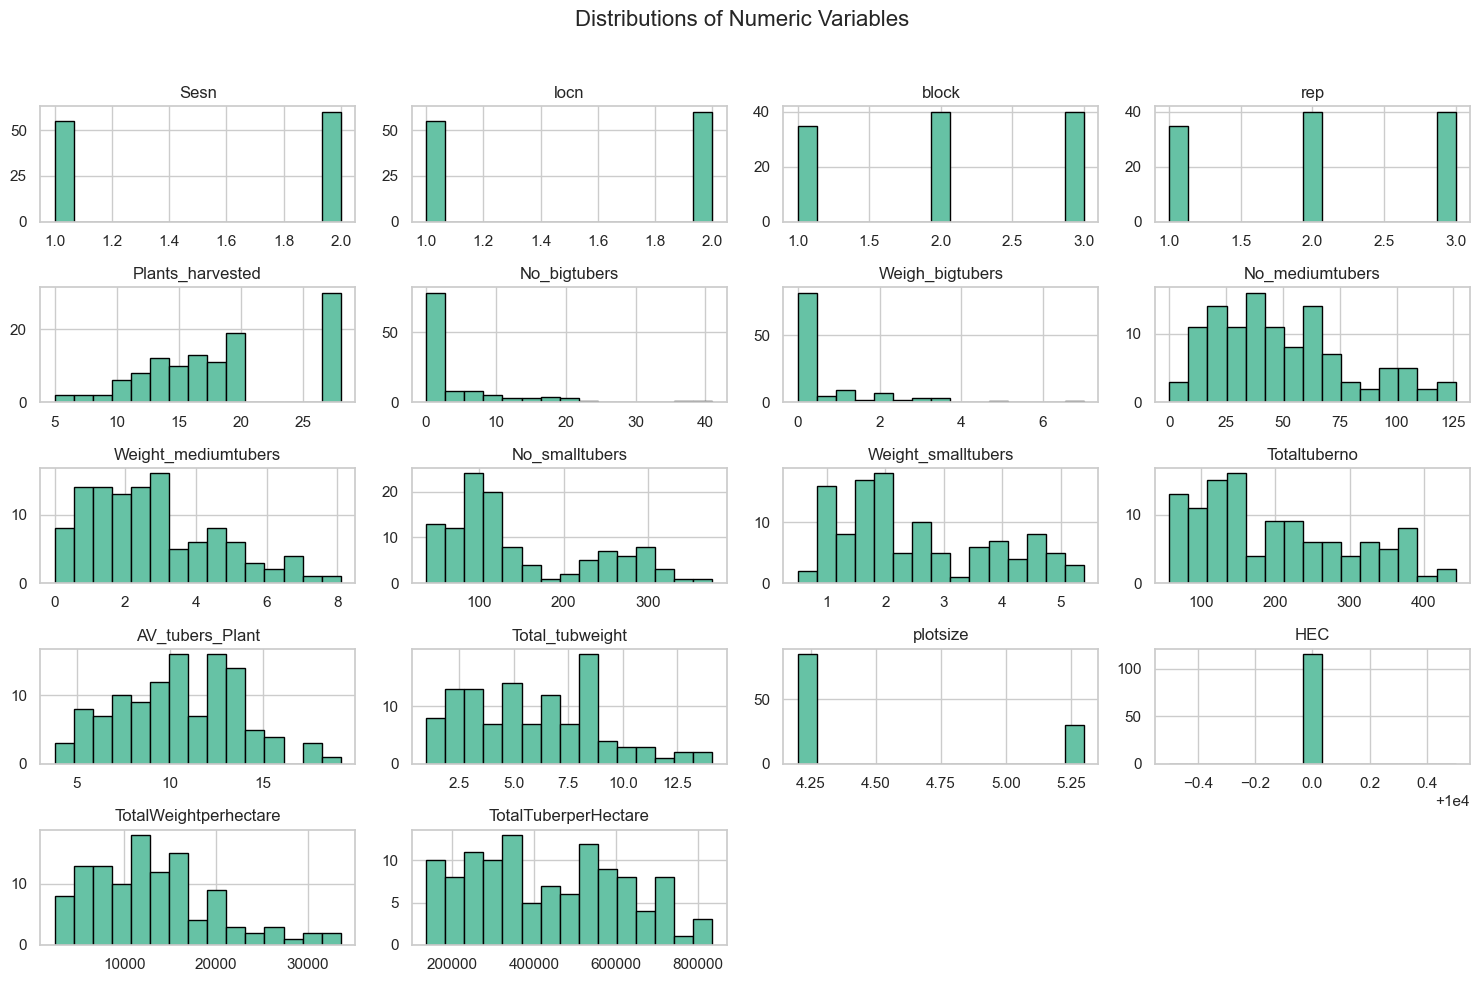

In [ ]:
# Visualize distributions of numeric variables

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Plot histograms for numeric columns, this shows how each numeric variable is distributed
df[numeric_cols].hist(bins=15, figsize=(15, 10), edgecolor='black')
plt.suptitle("Distributions of Numeric Variables", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## Boxplots for outlier detection

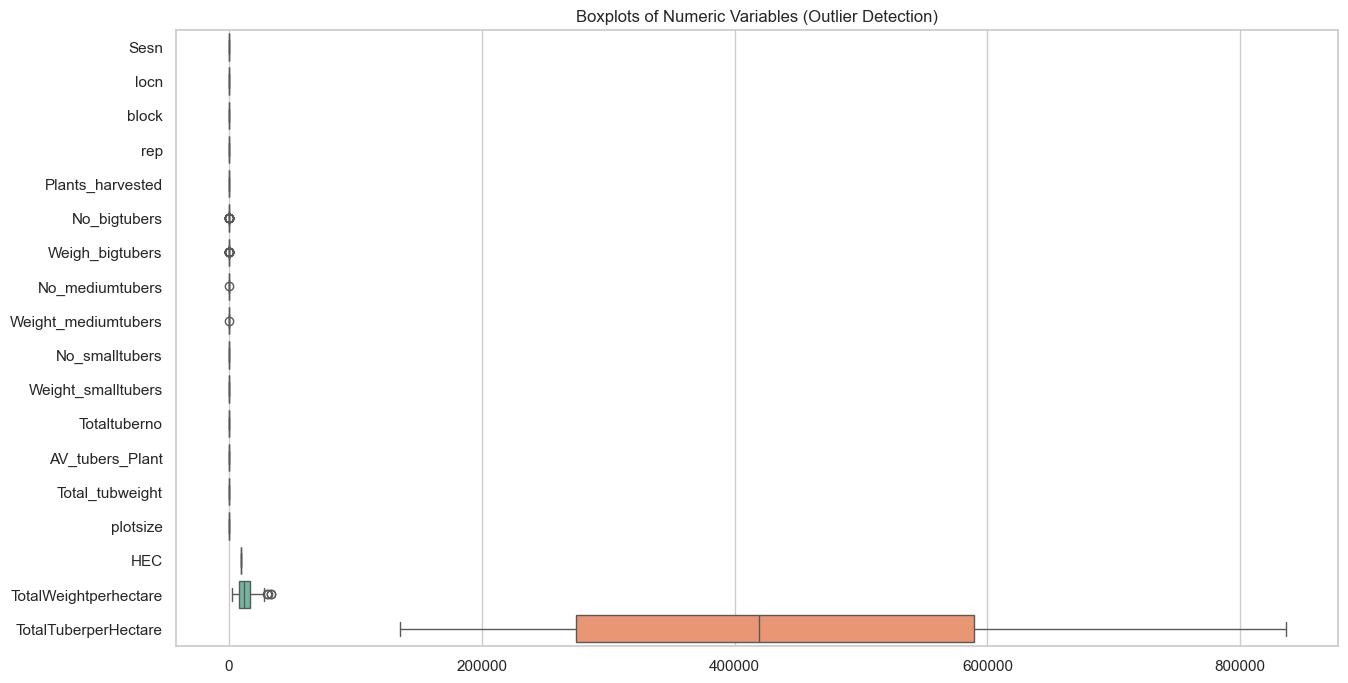

In [ ]:
# Detecting outliers visually using boxplots, boxplots highlight values that fall outside the IQR.

plt.figure(figsize=(15, 8))
sns.boxplot(data=df[numeric_cols], orient="h", palette="Set2")
plt.title("Boxplots of Numeric Variables (Outlier Detection)")
plt.show()

Boxplots highlight values that fall outside the interquartile range (IQR).  
Points far from the box are potential outliers that could skew averages or statistical tests. 

## Handling Outliers (IQR method)

In [30]:
# Handle outliers using the IQR method

def handle_outliers(df, cols):
    df_clean = df.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        # Cap extreme values at bounds
        df_clean[col] = np.where(df_clean[col] < lower, lower,
                                 np.where(df_clean[col] > upper, upper, df_clean[col]))
    return df_clean

# Apply function
df = handle_outliers(df, numeric_cols)

# Quick check
df.describe()

,Sesn,locn,block,rep,Plants_harvested,No_bigtubers,Weigh_bigtubers,No_mediumtubers,Weight_mediumtubers,No_smalltubers,Weight_smalltubers,Totaltuberno,AV_tubers_Plant,Total_tubweight,plotsize,HEC,TotalWeightperhectare,TotalTuberperHectare
count,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.0,115.000000,115.000000
mean,1.521739,1.521739,2.043478,2.043478,18.565217,3.163043,0.429130,49.504348,2.769783,146.252174,2.511304,199.773913,10.525355,5.897391,4.486957,10000.0,12990.233994,431822.336810
std,0.501713,0.501713,0.809931,0.809931,6.442908,4.852432,0.656712,29.876463,1.770372,87.351663,1.303354,102.555168,3.248495,3.040702,0.485134,0.0,6621.224610,184839.313619
min,1.000000,1.000000,1.000000,1.000000,5.000000,0.000000,0.000000,0.000000,0.000000,37.000000,0.500000,57.000000,3.800000,1.000000,4.200000,10000.0,2380.952381,135714.285714
25%,1.000000,1.000000,1.000000,1.000000,14.000000,0.000000,0.000000,26.500000,1.300000,84.000000,1.500000,115.500000,8.027778,3.400000,4.200000,10000.0,8095.238095,275000.000000
50%,2.000000,2.000000,2.000000,2.000000,18.000000,0.000000,0.000000,44.000000,2.500000,109.000000,2.100000,179.000000,10.666667,6.000000,4.200000,10000.0,11904.761905,419047.619048
75%,2.000000,2.000000,3.000000,3.000000,28.000000,5.500000,0.700000,65.500000,3.950000,221.000000,3.600000,273.500000,12.973684,8.150000,5.300000,10000.0,16421.832884,589285.714286
max,2.000000,2.000000,3.000000,3.000000,28.000000,13.750000,1.750000,124.000000,7.925000,376.000000,5.400000,443.000000,19.200000,14.100000,5.300000,10000.0,28911.725067,835849.056604


Outliers are capped at the lower (Q1 – 1.5 × IQR) and upper (Q3 + 1.5 × IQR) boundaries.  
Hence preserving the data size while reducing the effect of extreme values.  
After transformation, the `.describe()` output should show more stable minimum and maximum values.

## Investigating relationship between variables 


Pearson correlation = 0.584, p-value = 0.0000


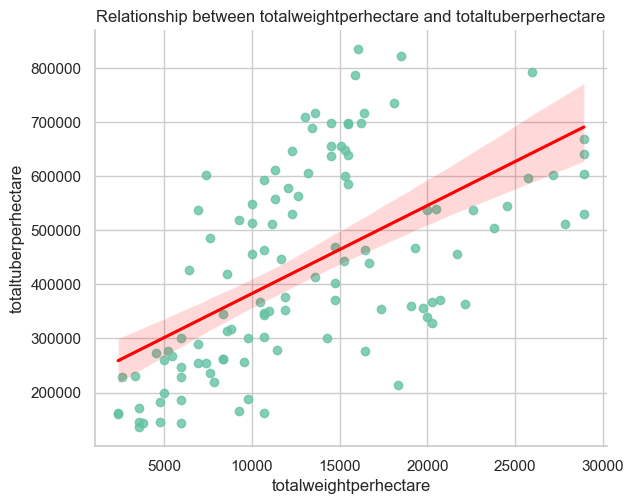

In [ ]:
# (a) Relationship between two continuous variables

# For instance: totalweightperhectare vs totaltuberperhectare
x = 'totalweightperhectare'
y = 'totaltuberperhectare'

# Calculate correlation
corr, p_val = stats.pearsonr(df[x], df[y])
print(f"Pearson correlation = {corr:.3f}, p-value = {p_val:.4f}")

# Visualize relationship
sns.lmplot(x=x, y=y, data=df, height=5, aspect=1.3, line_kws={'color': 'red'})
plt.title(f"Relationship between {x} and {y}")
plt.show()

We examine the relationship between **Total Weight per Hectare** and **Total Tuber per Hectare**.  
There is a **moderate positive correlation** between `totalweightperhectare` and `totaltuberperhectare`.  
This means that as the **number of tubers per hectare increases**, the **total weight of cassava harvested** also increases.  
Since the **p-value is less than 0.05**, the relationship is **statistically significant**, suggesting that the trend is unlikely to have occurred by chance.

totalweightperhectare: F = 2.238, p = 0.0695


C:\Users\Tesa\AppData\Local\Temp\ipykernel_20260\3886220062.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fert', y=col, data=df, palette='Set2')


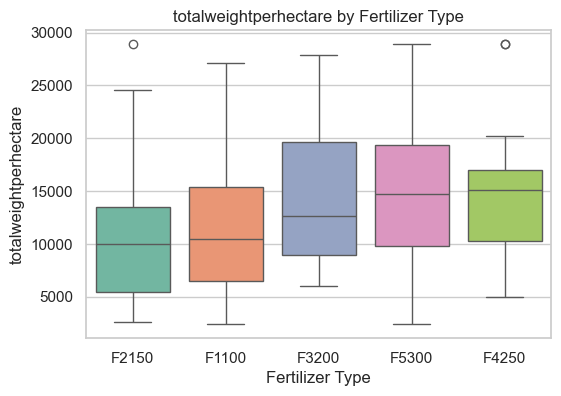

totaltuberperhectare: F = 0.404, p = 0.8051


C:\Users\Tesa\AppData\Local\Temp\ipykernel_20260\3886220062.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fert', y=col, data=df, palette='Set2')


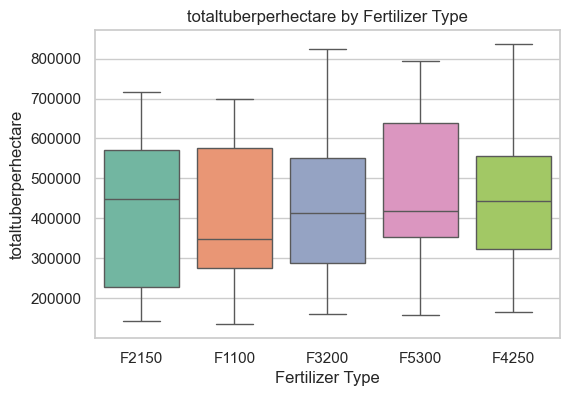

In [36]:
# (b) Relationship Between a Continuous and a Categorical Variable
# We are using boxplots for visualization and ANOVA for testing mean differences.

for col in ['totalweightperhectare', 'totaltuberperhectare']:
    groups = [group[col].values for name, group in df.groupby('fert')]
    f_stat, p_val = stats.f_oneway(*groups)
    print(f"{col}: F = {f_stat:.3f}, p = {p_val:.4f}")

    # Visualize
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='fert', y=col, data=df, palette='Set2')
    plt.title(f"{col} by Fertilizer Type")
    plt.xlabel("Fertilizer Type")
    plt.ylabel(col)
    plt.show()

This could mean that in the dataset the difference across fertilizer groups was not statistically significant for that test.

Chi-square = 0.000, p-value = 1.0000


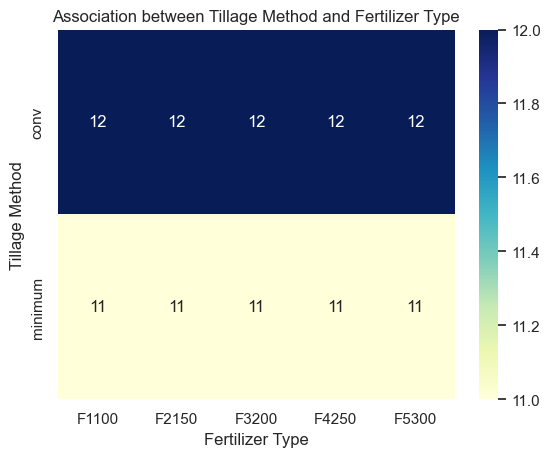

In [ ]:
#(c) Relationship Between Two Categorical Variables
# We’ll use a Chi-square test of independence and a heatmapTwo categorical variables

# Create contingency table
cont_table = pd.crosstab(df['tillage'], df['fert'])

# Perform chi-square test
chi2, p, dof, expected = stats.chi2_contingency(cont_table)

print(f"Chi-square = {chi2:.3f}, p-value = {p:.4f}")

# Visualize
sns.heatmap(cont_table, annot=True, cmap="YlGnBu", fmt='g')
plt.title("Association between Tillage Method and Fertilizer Type")
plt.xlabel("Fertilizer Type")
plt.ylabel("Tillage Method")
plt.show()

This indicates no evidence of association in this contingency table.

## Fertilizer and Tillage Effects on Yield

Effect of Fertilizer on totalweightperhectare: F = 2.238, p = 0.0695


C:\Users\Tesa\AppData\Local\Temp\ipykernel_20260\3102721074.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fert', y=col, data=df, palette='pastel')


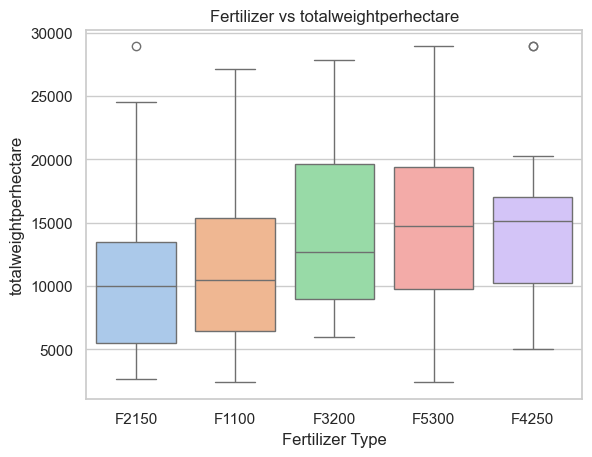

Effect of Fertilizer on totaltuberperhectare: F = 0.404, p = 0.8051


C:\Users\Tesa\AppData\Local\Temp\ipykernel_20260\3102721074.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fert', y=col, data=df, palette='pastel')


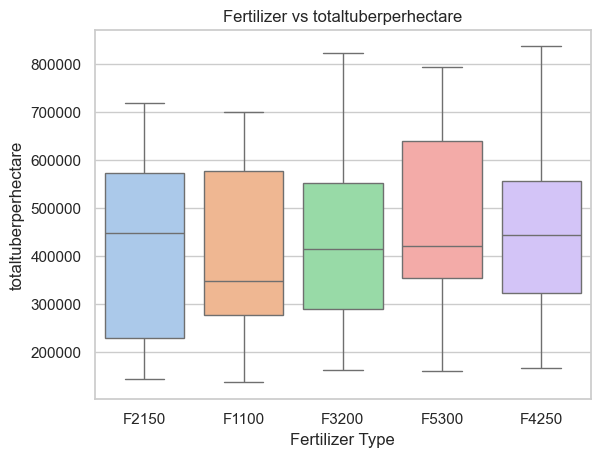

In [38]:
# Fertilizer effect on yield (ANOVA test)

for col in ['totalweightperhectare', 'totaltuberperhectare']:
    groups = [group[col].values for name, group in df.groupby('fert')]
    f_stat, p_val = stats.f_oneway(*groups)
    print(f"Effect of Fertilizer on {col}: F = {f_stat:.3f}, p = {p_val:.4f}")

    sns.boxplot(x='fert', y=col, data=df, palette='pastel')
    plt.title(f"Fertilizer vs {col}")
    plt.xlabel("Fertilizer Type")
    plt.ylabel(col)
    plt.show()

In this dataset, fertilizer type did not show a statistically significant effect on the two outcome variables.

Effect of Tillage on totalweightperhectare: t = 0.504, p = 0.6156


C:\Users\Tesa\AppData\Local\Temp\ipykernel_20260\2181766825.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='tillage', y=col, data=df, palette='Set2')


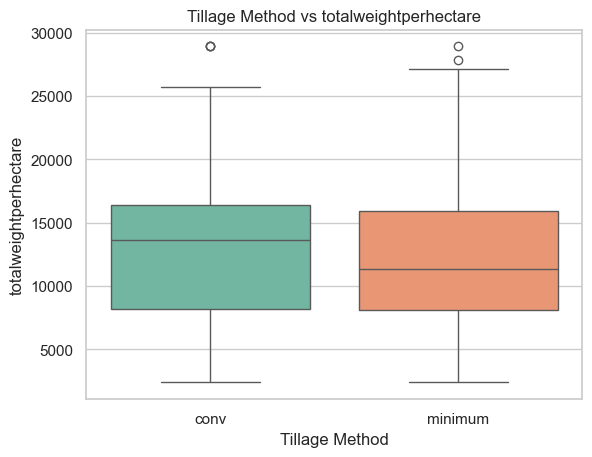

Effect of Tillage on totaltuberperhectare: t = 1.380, p = 0.1703


C:\Users\Tesa\AppData\Local\Temp\ipykernel_20260\2181766825.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='tillage', y=col, data=df, palette='Set2')


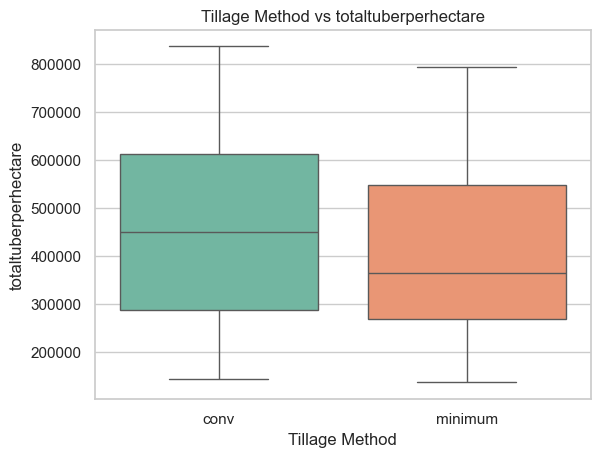

In [39]:
# Tillage effect on yield using independent t-test

for col in ['totalweightperhectare', 'totaltuberperhectare']:
    conv = df[df['tillage'] == 'conv'][col]
    minimum = df[df['tillage'] == 'minimum'][col]
    t_stat, p_val = stats.ttest_ind(conv, minimum)
    print(f"Effect of Tillage on {col}: t = {t_stat:.3f}, p = {p_val:.4f}")

    sns.boxplot(x='tillage', y=col, data=df, palette='Set2')
    plt.title(f"Tillage Method vs {col}")
    plt.xlabel("Tillage Method")
    plt.ylabel(col)
    plt.show()

No statistically significant differences between tillage methods in this dataset

## Association Between Fertilizers Across Seasons

In [40]:
# Prepare data for association mining

# Create a small dataframe of relevant columns
assoc_data = df[['sesn', 'fert']].drop_duplicates()

# Convert to a one-hot encoded format
basket = pd.crosstab(assoc_data['sesn'], assoc_data['fert'])

# Preview the basket format
basket.head()

fert,F1100,F2150,F3200,F4250,F5300
sesn,,,,,
1.0,1,1,1,1,1
2.0,1,1,1,1,1


In [51]:
%pip install mlxtend


Note: you may need to restart the kernel to use updated packages.


In [49]:
# Importing mlxtend for association rule mining
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder


In [50]:
# Apply Apriori algorithm and generate association rules

frequent_items = apriori(basket, min_support=0.1, use_colnames=True)
rules = association_rules(frequent_items, metric="lift", min_threshold=1.0)

# Display top rules
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

c:\Users\Tesa\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
c:\Users\Tesa\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


,antecedents,consequents,support,confidence,lift
0,(F1100),(F2150),1.0,1.0,1.0
1,(F2150),(F1100),1.0,1.0,1.0
2,(F1100),(F3200),1.0,1.0,1.0
3,(F3200),(F1100),1.0,1.0,1.0
4,(F4250),(F1100),1.0,1.0,1.0
5,(F1100),(F4250),1.0,1.0,1.0
6,(F5300),(F1100),1.0,1.0,1.0
7,(F1100),(F5300),1.0,1.0,1.0
8,(F2150),(F3200),1.0,1.0,1.0
9,(F3200),(F2150),1.0,1.0,1.0


## Predictive model for “Plants_harvested”

In [42]:
# Prepare data for predictive modeling

# Select numeric features
features = ['no_bigtubers', 'weigh_bigtubers', 'no_mediumtubers',
            'weight_mediumtubers', 'no_smalltubers', 'weight_smalltubers',
            'totalweightperhectare', 'totaltuberperhectare']

X = df[features]
y = df['plants_harvested']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
# Training the model

model = LinearRegression()
model.fit(X_train, y_train)

# Coefficients
coeff_df = pd.DataFrame(model.coef_, index=features, columns=['Coefficient'])
coeff_df

,Coefficient
no_bigtubers,-0.143941
weigh_bigtubers,-0.936713
no_mediumtubers,0.249793
weight_mediumtubers,-4.032542
no_smalltubers,0.103009
weight_smalltubers,-0.693580
totalweightperhectare,0.000655
totaltuberperhectare,-0.000032


R² score: 0.809
Root Mean Squared Error (RMSE): 2.930


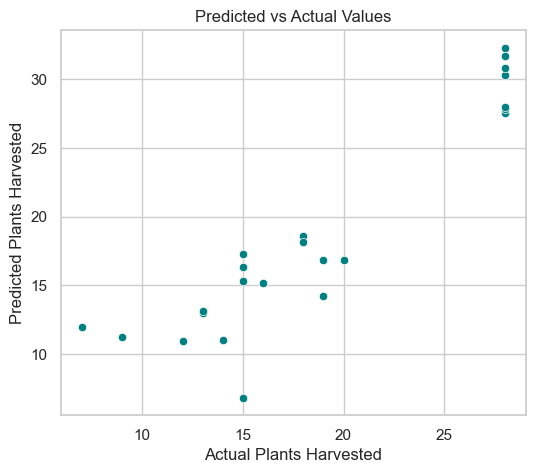

In [44]:
# Model evaluation

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² score: {r2:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")

# Scatter plot of predicted vs actual
plt.figure(figsize=(6,5))
sns.scatterplot(x=y_test, y=y_pred, color='teal')
plt.xlabel("Actual Plants Harvested")
plt.ylabel("Predicted Plants Harvested")
plt.title("Predicted vs Actual Values")
plt.show()

In [45]:
# Savng the cleaned data
df.to_csv("Cassava_Yield_Data_Cleaned.csv", index=False)